In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
cols = ["age", "workclass", "fnlwgt", "education", "education_num", 
        "marital_status", "occupation", "relationship", "race", "sex",
        "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"]
df = pd.read_csv(url, names=cols, skipinitialspace=True)

df.replace('?', np.nan, inplace=True)
print(df.isnull().sum())

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64
(32561, 15)
age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
dtype: object
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
cap

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


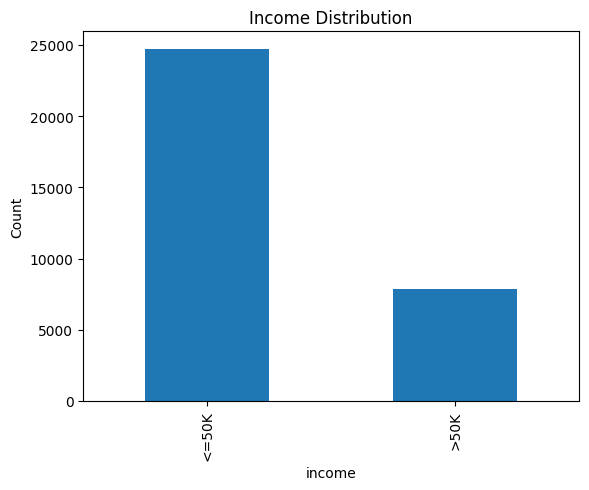

In [2]:
df['income'].value_counts().plot(kind='bar')
plt.title('Income Distribution')
plt.ylabel('Count')
plt.show()

Substantially more individuals have an income that is equal to or less than 50,000 USD compared to those with more than 50k annually.

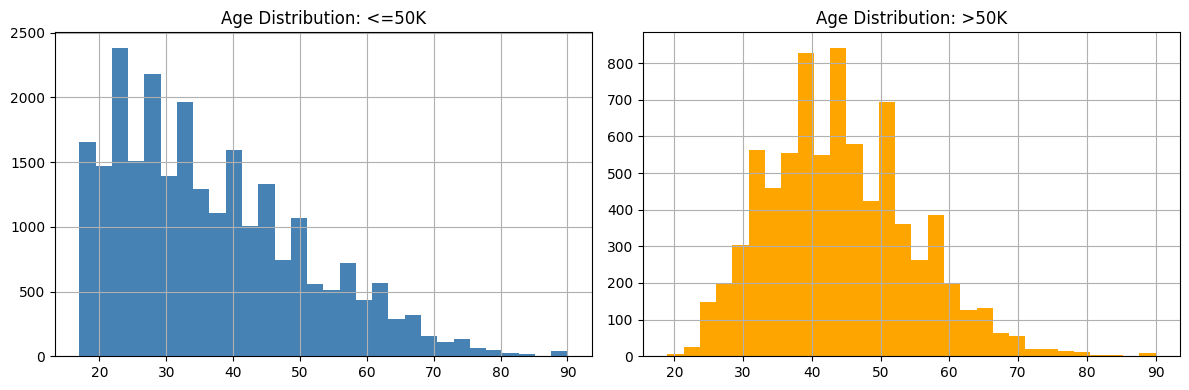

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['income'] == '<=50K']['age'].hist(bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution: <=50K')

df[df['income'] == '>50K']['age'].hist(bins=30, ax=axes[1], color='orange')
axes[1].set_title('Age Distribution: >50K')

plt.tight_layout()
plt.show()

Younger people tend to be more likely to earn <= 50K than older people.

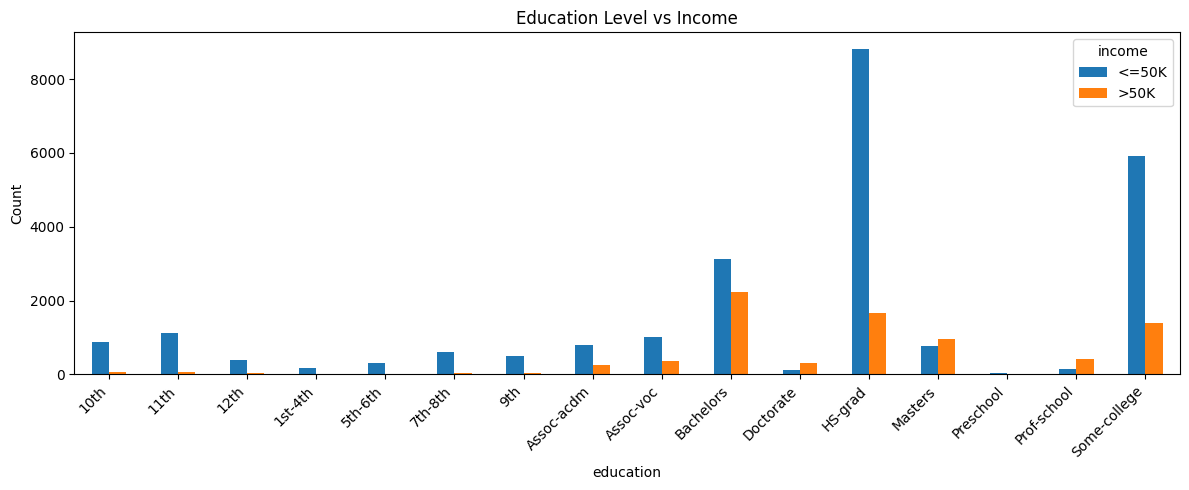

In [4]:
edu_income = df.groupby(['education', 'income']).size().unstack()
edu_income.plot(kind='bar', figsize=(12, 5))
plt.title('Education Level vs Income')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

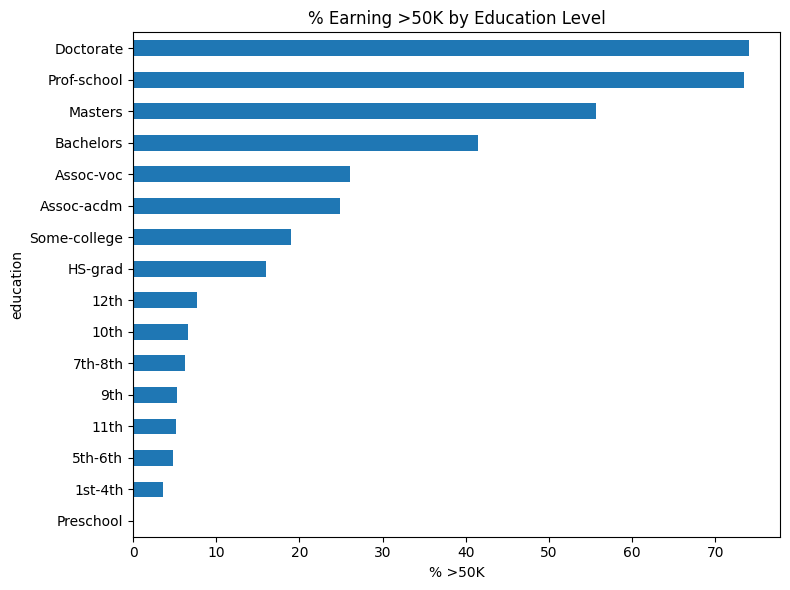

In [6]:
edu_pct = df.groupby('education')['income'].apply(
    lambda x: (x == '>50K').mean() * 100
).sort_values()

edu_pct.plot(kind='barh', figsize=(8, 6))
plt.title('% Earning >50K by Education Level')
plt.xlabel('% >50K')
plt.tight_layout()
plt.show()

Education level is directly correlated with income, with degree holders being substantially more likely to earn more than 50,000 a year compared to HS grads.

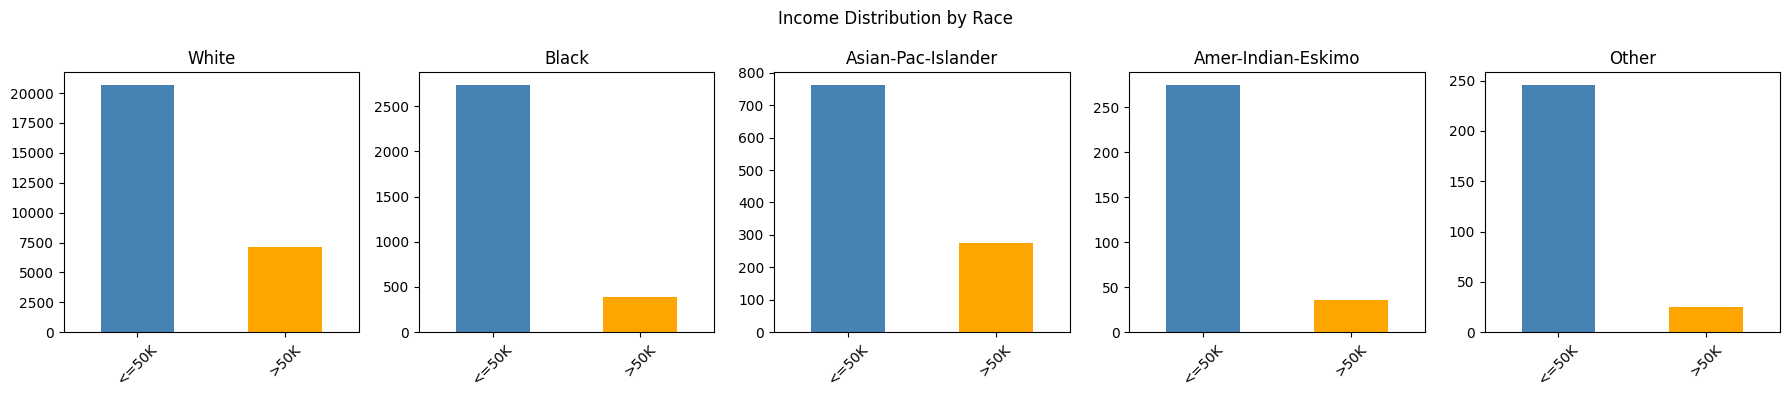

In [13]:
races = df['race'].unique()
fig, axes = plt.subplots(1, len(races), figsize=(18, 4))

for ax, race in zip(axes, races):
    df[df['race'] == race]['income'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'orange'])
    ax.set_title(race)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Income Distribution by Race')
plt.tight_layout()
plt.show()

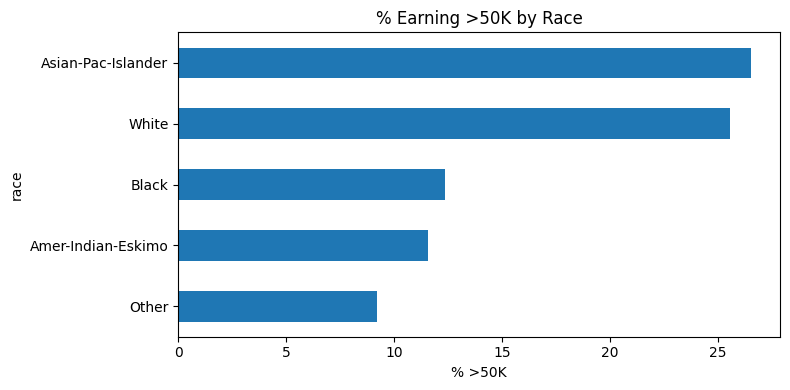

In [14]:
race_pct = df.groupby('race')['income'].apply(
    lambda x: (x == '>50K').mean() * 100
).sort_values()

race_pct.plot(kind='barh', figsize=(8, 4))
plt.title('% Earning >50K by Race')
plt.xlabel('% >50K')
plt.tight_layout()
plt.show()

White and AAPI respondents were much more likely to earn >50K compared to Black, Indigenous, and Other respondents.

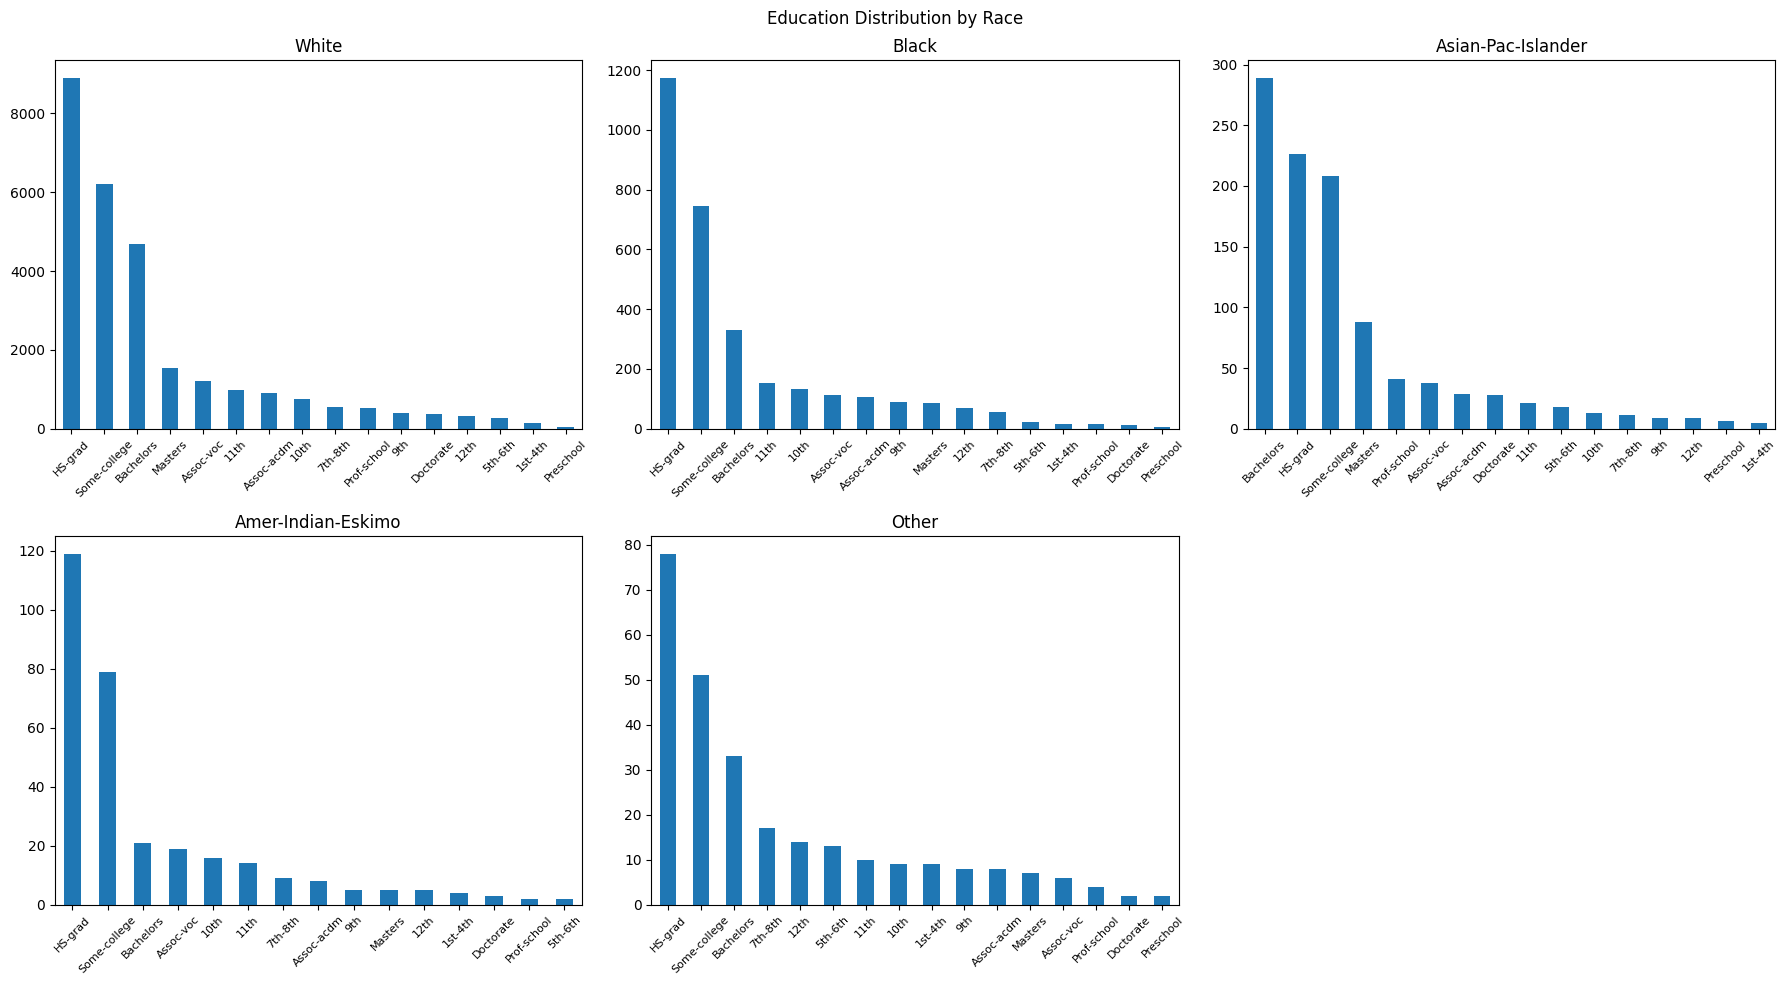

In [19]:
races = df['race'].unique()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, race in zip(axes, races):
    df[df['race'] == race]['education'].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(race)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

axes[-1].set_visible(False)

plt.suptitle('Education Distribution by Race')
plt.tight_layout()
plt.show()

AAPI respondents were more likely to have had a college education compared to White respondents, and substantially more likely than Black, Indigenous, and Other respondents. Furthermore, AAPI respondents were the only group who had more BS holders than those who only graduated high school.

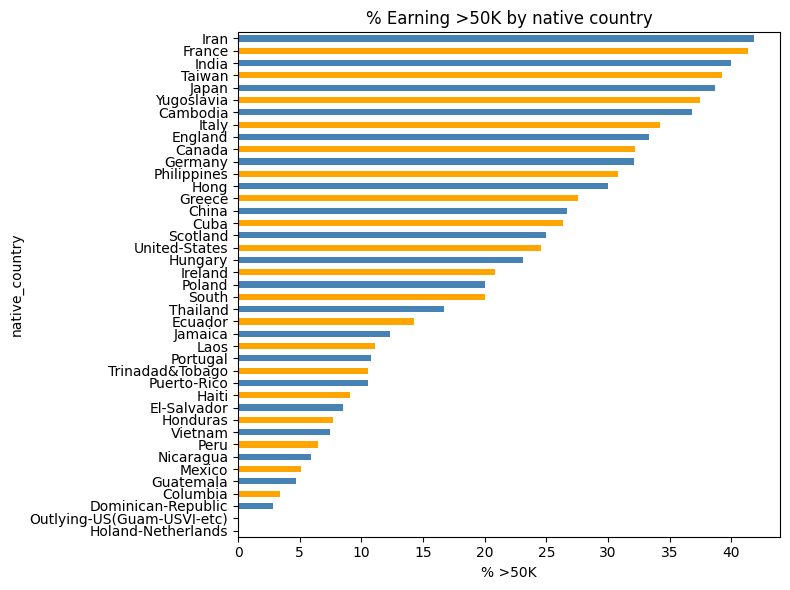

In [25]:
edu_pct = df.groupby('native_country')['income'].apply(
    lambda x: (x == '>50K').mean() * 100
).sort_values()

edu_pct.plot(kind='barh', figsize=(8, 6), color=['steelblue', 'orange'])
plt.title('% Earning >50K by native country')
plt.xlabel('% >50K')
plt.tight_layout()
plt.show()

Individuals from Iran, France, and India were twice as likely to make >50K per year, with ~38-40% of these groups making more than 50K a year compared to Americans, where only 25% made more than 50K a year. This is likely due to immigration bias, as people who emigrate for work tend to be higher-skilled and more educated than the general population of their home country.

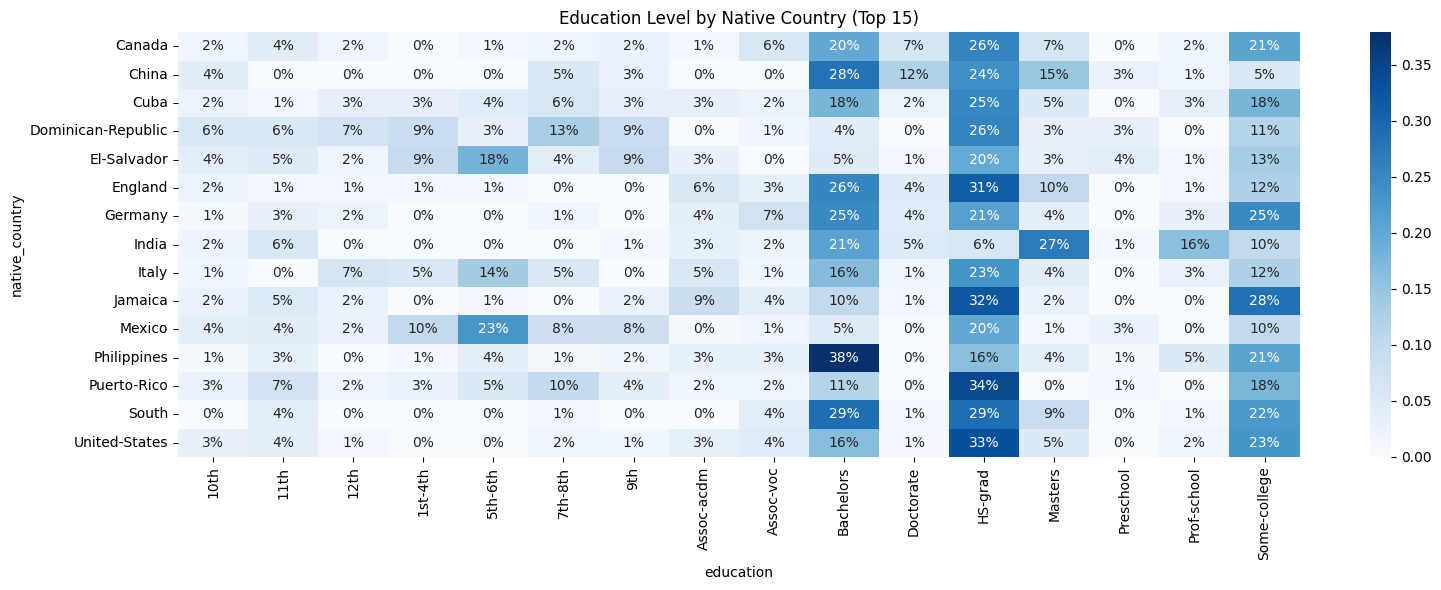

In [41]:
top_countries = df['native_country'].value_counts().head(15).index
df_filtered = df[df['native_country'].isin(top_countries)]

pivot = df_filtered.groupby(['native_country', 'education']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

plt.figure(figsize=(16, 6))
sns.heatmap(pivot_pct, cmap='Blues', annot=True, fmt='.0%')
plt.title('Education Level by Native Country (Top 15)')
plt.tight_layout()
plt.show()

I actually did not know that 38% of Filipino immigrants had a bachelors degree.
27% of Indian immigrants had a Masters degree, followed by Chinese immigrants at 15%.

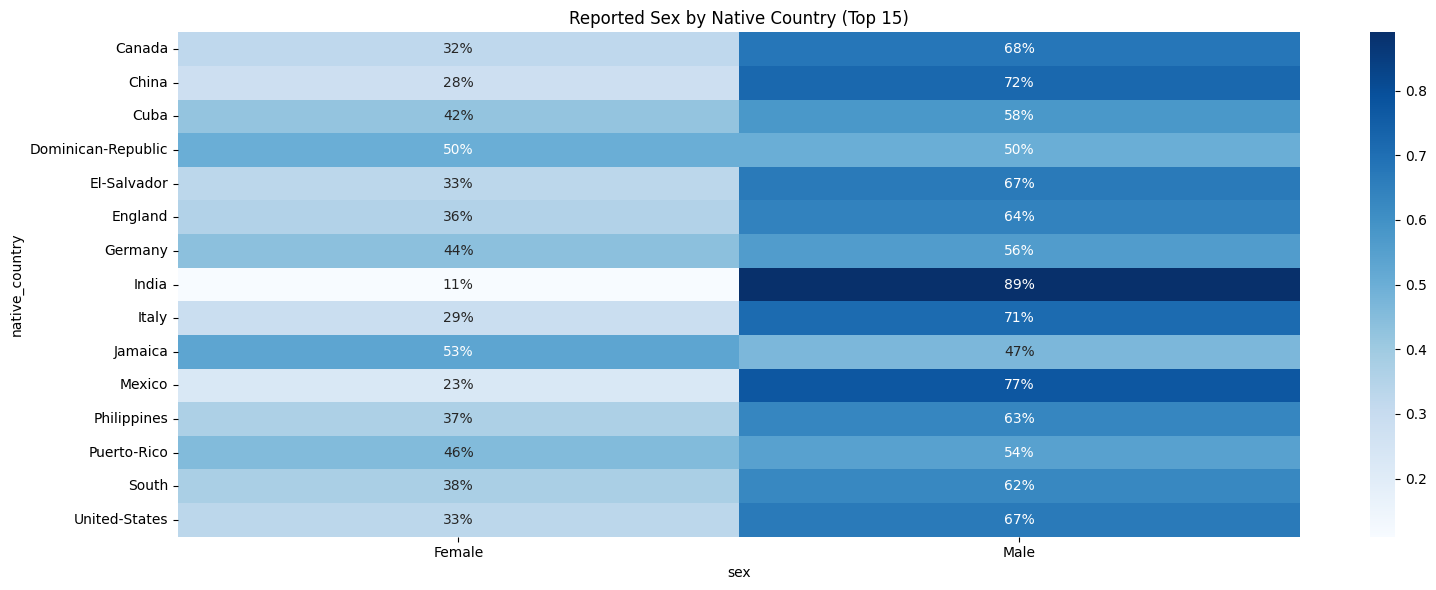

In [ ]:
top_countries = df['native_country'].value_counts().head(15).index
df_filtered = df[df['native_country'].isin(top_countries)]

pivot = df_filtered.groupby(['native_country', 'sex']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

plt.figure(figsize=(16, 6))
sns.heatmap(pivot_pct, cmap='Blues', annot=True, fmt='.0%')
plt.title('Reported Sex by Native Country (Top 15)')
plt.tight_layout()
plt.show()

Indian respondents tended to be overwhelmingly male, with 89% of respondents identifying as male.
Mexican and Italian groups tended to be mostly male, with 77% and 71% of respondents identifying as male.
Dominican respondents were a 50/50 split, with an equal amount of respondents identifying as male or female.
Jamaican respondents tended to be slightly more female, with 53% of respondents identifying as female.